In [3]:
from pathlib import Path

from draftslice.core.io import load_image

files = sorted(Path("../data/images").glob("*.jpg"))

In [ ]:
import ipywidgets as widgets
from IPython.display import display
from matplotlib import pyplot as plt

file_names = [f.name for f in files]


def _view_img(filename: str):

    path = next(f for f in files if f.name == filename)
    img = load_image(str(path))
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.title(img.shape)
    plt.axis("off")
    plt.show()
    return img


ui = widgets.interactive(_view_img, filename=file_names)
display(ui)

interactive(children=(Dropdown(description='filename', options=('1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg…

In [134]:
import cv2

img: cv2.typing.MatLike = ui.result

In [135]:
def resize_to_long_side(image, long_side: int):
    current_side = max(image.shape[:2])
    if current_side == long_side:
        return image

    factor = long_side / float(current_side)
    interpolation = cv2.INTER_AREA if factor < 1 else cv2.INTER_CUBIC
    width = round(image.shape[1] * factor)
    height = round(image.shape[0] * factor)
    return cv2.resize(image, (width, height), interpolation=interpolation)


resized_img = resize_to_long_side(img, 2000)

In [136]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    text_recognition_model_dir="../models/cyrillic_PP-OCRv5_mobile_rec_infer",
    text_detection_model_dir="../models/PP-OCRv6_medium_det_infer",
    text_recognition_model_name="cyrillic_PP-OCRv5_mobile_rec",
    text_detection_model_name="PP-OCRv6_medium_det",
    text_rec_score_thresh=0.3,
)

Creating model: ('PP-OCRv6_medium_det', '../models/PP-OCRv6_medium_det_infer', None)
Creating model: ('cyrillic_PP-OCRv5_mobile_rec', '../models/cyrillic_PP-OCRv5_mobile_rec_infer', None)


In [137]:
import numpy as np


def rotate_image(image, angle):
    """Поворот изображения на angle градусов, холст расширяется под новый размер.
    Возвращает повёрнутое изображение и матрицу поворота (нужна, чтобы потом перевести
    координаты боксов, найденных на повёрнутом изображении, обратно в оригинал)."""
    h, w = image.shape[:2]
    center = (w / 2, h / 2)
    mat = cv2.getRotationMatrix2D(center, angle, 1.0)
    cos = np.abs(mat[0, 0])
    sin = np.abs(mat[0, 1])
    new_w = int((h * sin) + (w * cos))
    new_h = int((h * cos) + (w * sin))
    mat[0, 2] += (new_w - w) / 2
    mat[1, 2] += (new_h - h) / 2

    rotated = image if angle % 360 < 1e-7 else cv2.warpAffine(image, mat, (new_w, new_h), flags=cv2.INTER_CUBIC)
    return rotated, mat


def multi_rotate_image(image, angles: list[int]):
    rotated_images = []
    matrices = []
    for angle in angles:
        rotated, mat = rotate_image(image, angle)
        rotated_images.append(rotated)
        matrices.append(mat)
    return rotated_images, matrices

In [ ]:
angles = [0, 90, 270]
rotated_imgs, matrices = multi_rotate_image(img, angles)

# ocr.predict() уже возвращает list (обёртка сама разворачивает свой генератор),
# на одно изображение - один результат.
results = [ocr.predict(ri)[0] for ri in rotated_imgs]

107 после фильтра по буквам/цифрам -> 43 после NMS


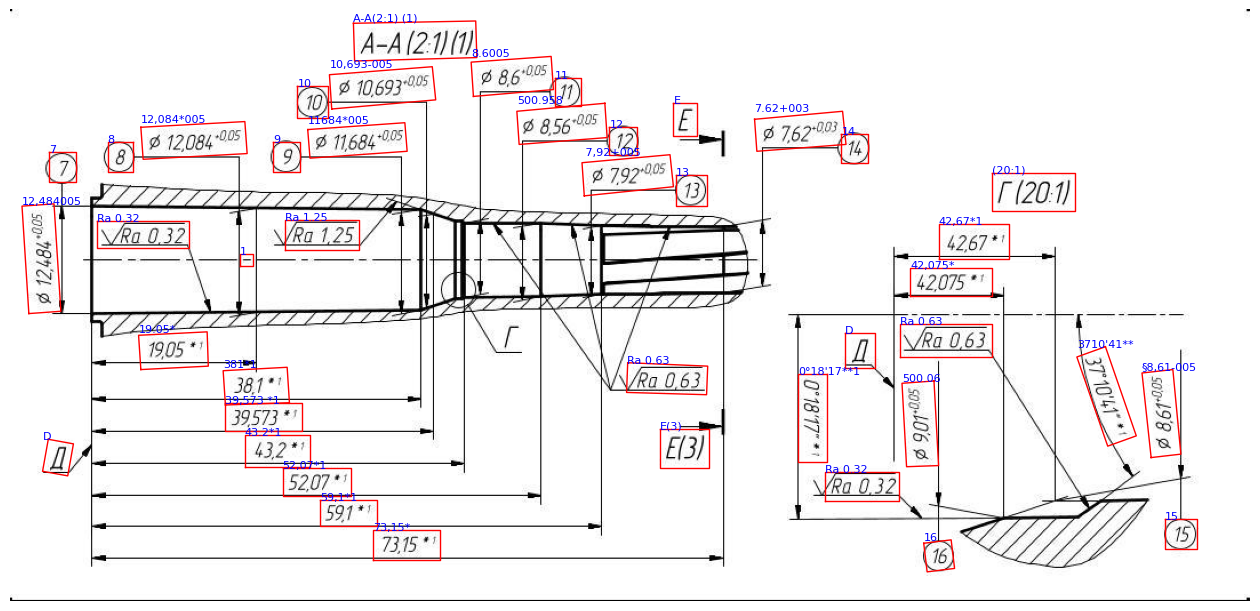

In [ ]:
def polys_to_original(polys, mat):
    """Переводит точки полигонов из системы координат повёрнутого изображения в оригинал."""
    inv = cv2.invertAffineTransform(mat)
    return [cv2.transform(np.array([poly], dtype=np.float32), inv)[0] for poly in polys]


def _poly_bbox(poly):
    return poly[:, 0].min(), poly[:, 1].min(), poly[:, 0].max(), poly[:, 1].max()


def _bbox_iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def deduplicate_by_overlap(detections, iou_threshold: float = 0.3):
    """NMS: если один и тот же текст найден в нескольких поворотах, боксы в координатах
    оригинала перекрываются - оставляем запись с максимальным score в каждой такой группе."""
    ordered = sorted(detections, key=lambda d: d["score"], reverse=True)
    kept, kept_boxes = [], []
    for d in ordered:
        box = _poly_bbox(d["poly"])
        if any(_bbox_iou(box, kb) > iou_threshold for kb in kept_boxes):
            continue
        kept.append(d)
        kept_boxes.append(box)
    return kept


detections = []
for angle, mat, res in zip(angles, matrices, results):
    polys_original = polys_to_original(res["rec_polys"], mat)
    for text, score, poly in zip(res["rec_texts"], res["rec_scores"], polys_original):
        if not any(ch.isalnum() for ch in text):
            continue
        detections.append({"text": text, "score": score, "poly": poly, "found_at_angle": angle})

deduped = deduplicate_by_overlap(detections)
print(f"{len(detections)} после фильтра по буквам/цифрам -> {len(deduped)} после NMS")

plt.figure(figsize=(16, 8))
plt.imshow(img)
for d in deduped:
    poly = d["poly"]
    plt.plot([*poly[:, 0], poly[0, 0]], [*poly[:, 1], poly[0, 1]], color="red", linewidth=1)
    plt.text(poly[:, 0].min(), poly[:, 1].min(), d["text"], color="blue", fontsize=8)
plt.axis("off")
plt.show()